# Bays (2014) Figure 4 — Robustness Under Model Variations

In [3]:
import sys
from pathlib import Path
PROJECT_ROOT = str(Path.cwd().parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import time

from core.encoder.gaussian_process import (
    generate_neuron_population, periodic_rbf_kernel, sample_gp_function,
)
from core.encoder.divisive_normalization import dn_pointwise
from core.encoder.poisson_spike import generate_spikes

print(f"Project root: {PROJECT_ROOT}")
import matplotlib.gridspec as gridspec

Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1


In [4]:
def compute_log_likelihood(counts, g, T_d):
    log_g = np.log(np.maximum(g, 1e-30))
    return counts @ log_g - T_d * np.sum(g, axis=0)

def compute_circular_error(theta_true, theta_hat):
    return np.angle(np.exp(1j * (theta_hat - theta_true)))

def circular_variance(errors):
    return 1.0 - np.abs(np.mean(np.exp(1j * errors)))

def circular_kurtosis(errors):
    V = circular_variance(errors)
    rho2 = np.abs(np.mean(np.exp(2j * errors)))
    kappa2 = 1.0 - rho2
    return kappa2 / max(V**2, 1e-15) if V > 1e-10 else 0.0

def compute_deviation_from_normal(errors, n_bins=50):
    from scipy.stats import vonmises
    bin_edges = np.linspace(-np.pi, np.pi, n_bins + 1)
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    emp, _ = np.histogram(errors, bins=bin_edges, density=True)
    V = circular_variance(errors)
    kappa_fit = max(0.01, 1.0 / V - 1) if V > 0.01 else 100.0
    vm_pdf = vonmises.pdf(centers, kappa_fit)
    return {'bin_centers': centers, 'empirical': emp, 'normal_fit': vm_pdf,
            'deviation': emp - vm_pdf}

In [5]:
def generate_population(M, n_theta, lengthscale, n_locations=1, seed=42):
    population = generate_neuron_population(
        n_neurons=M, n_orientations=n_theta, n_locations=n_locations,
        base_lengthscale=lengthscale, lengthscale_variability=0.0, seed=seed)
    thetas = population[0]['orientations']
    f_all = []
    for loc in range(n_locations):
        f_loc = np.array([population[n]['f_samples'][loc, :] for n in range(M)])
        f_all.append(f_loc)
    return thetas, f_all

In [6]:
N_THETA = 64; N_TRIALS = 3000; T_D = 0.1; SIGMA_SQ = 1e-6
LAMBDA_BROAD = 1.0; LAMBDA_NARROW = 0.3; BASELINE_FRAC = 0.25
GAMMAS = [2, 8, 32, 128]; M_POP = 100; SEED = 42; N_BINS = 50

In [7]:
def make_gp_pop(M, lam, seed):
    thetas, f_all = generate_population(M, N_THETA, lam, 1, seed)
    return thetas, np.exp(f_all[0])

def make_gp_baseline(M, lam, bl_frac, seed):
    thetas, g = make_gp_pop(M, lam, seed)
    if bl_frac > 1e-10:
        peak = np.mean(np.max(g, axis=1))
        g = g + bl_frac * peak / (1 - bl_frac)
    return thetas, g

def make_heterogeneous(M, seed):
    rng = np.random.RandomState(seed)
    thetas = np.linspace(-np.pi, np.pi, N_THETA, endpoint=False)
    g = np.zeros((M, N_THETA))
    for i in range(M):
        lam_i = max(0.05, rng.normal(0.5, 0.2))
        amp_i = max(0.01, rng.normal(1.0, 0.3))
        bl_i = max(0, rng.normal(0.1, 0.05))
        K = periodic_rbf_kernel(thetas, lam_i)
        f_i = sample_gp_function(K, rng)
        g[i] = amp_i * np.exp(f_i) + bl_i
    return thetas, g

def make_cosine(M, seed):
    rng = np.random.RandomState(seed)
    thetas = np.linspace(-np.pi, np.pi, N_THETA, endpoint=False)
    prefs = rng.uniform(-np.pi, np.pi, M)
    g = np.zeros((M, N_THETA))
    for i in range(M):
        amp = max(0.01, rng.normal(1.0, 0.3))
        bl = max(0, rng.normal(0.1, 0.05))
        g[i] = amp * np.maximum(0, np.cos(thetas - prefs[i])) + bl
    return thetas, g

In [8]:
t0 = time.time()
panel_configs = {
    'a': ('Broad GP', lambda: make_gp_pop(M_POP, LAMBDA_BROAD, SEED)),
    'b': ('Narrow GP', lambda: make_gp_pop(M_POP, LAMBDA_NARROW, SEED+100)),
    'c': ('Baseline', lambda: make_gp_baseline(M_POP, LAMBDA_NARROW, BASELINE_FRAC, SEED+200)),
    'd': ('Heterogeneous', lambda: make_heterogeneous(M_POP, SEED+300)),
    'e': ('Cosine', lambda: make_cosine(M_POP, SEED+400)),
}
panels = {}
for pid, (title, gen_fn) in panel_configs.items():
    thetas, g = gen_fn()
    panels[pid] = {'title': title, 'thetas': thetas, 'g': g, 'results': {}}
    for gam in GAMMAS:
        rng = np.random.RandomState(SEED + int(gam))
        errors = np.empty(N_TRIALS)
        for t in range(N_TRIALS):
            idx = rng.randint(N_THETA)
            rates = dn_pointwise(g[:, idx], gam, SIGMA_SQ)
            counts = generate_spikes(rates, T_D, rng)
            ll = compute_log_likelihood(counts, g, T_D)
            errors[t] = compute_circular_error(thetas[idx], thetas[np.argmax(ll)])
        panels[pid]['results'][gam] = compute_deviation_from_normal(errors, N_BINS)
    print(f"  Panel {pid} ({title}) done ({time.time()-t0:.0f}s)")
print(f"All done in {time.time()-t0:.1f}s")

  Panel a (Broad GP) done (1s)
  Panel b (Narrow GP) done (1s)
  Panel c (Baseline) done (2s)
  Panel d (Heterogeneous) done (2s)
  Panel e (Cosine) done (3s)
All done in 2.8s


/var/folders/yj/t42cs9hx1vggcmxsxd8zgrhc0000gn/T/ipykernel_39122/772013249.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.95]); plt.show()


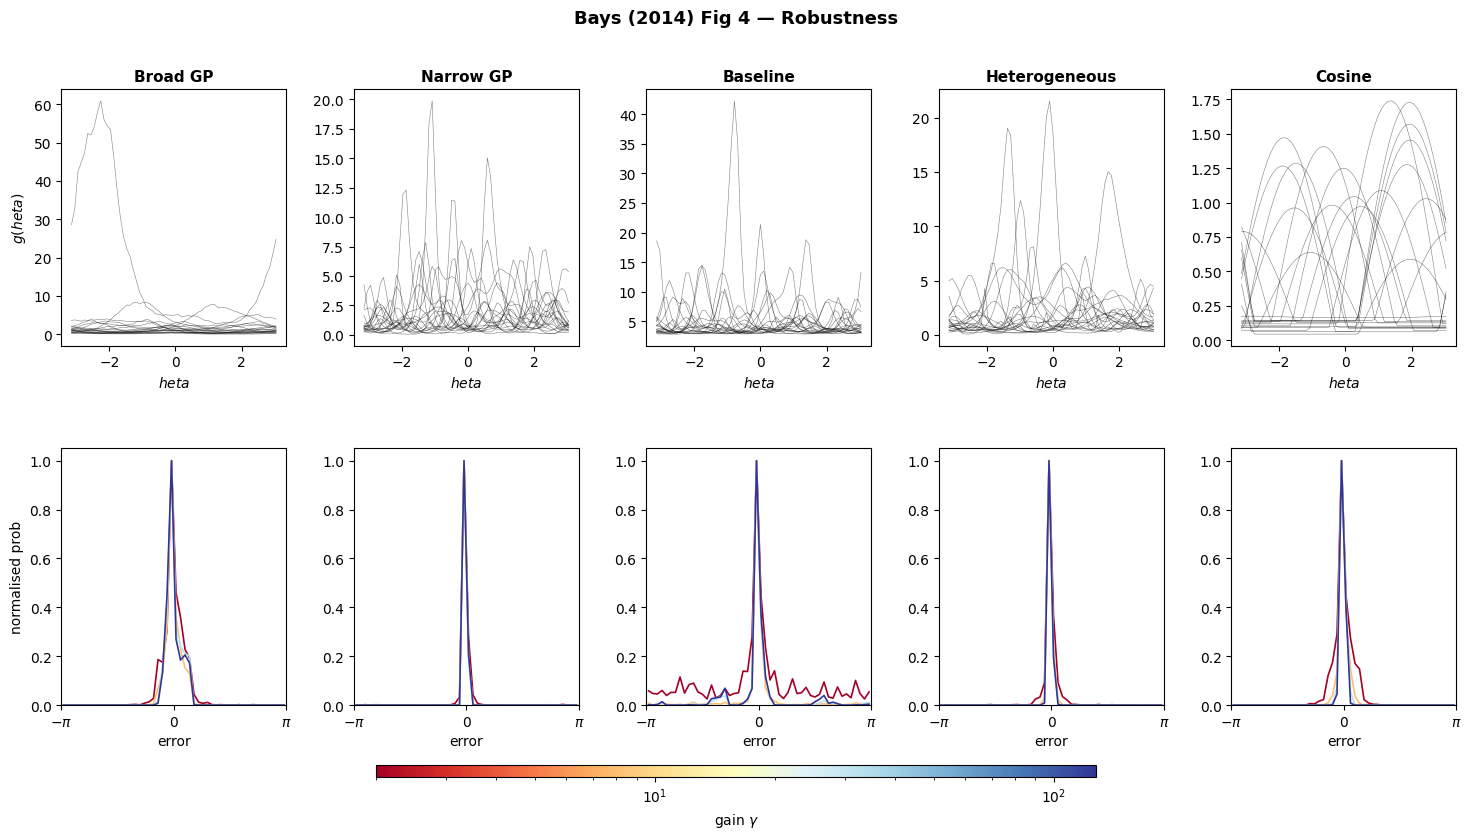

In [9]:
fig = plt.figure(figsize=(18, 8))
gs = gridspec.GridSpec(2, 5, hspace=0.4, wspace=0.3)
gain_cmap = plt.cm.RdYlBu
gain_norm = mcolors.LogNorm(vmin=min(GAMMAS), vmax=max(GAMMAS))
for col, pid in enumerate(['a','b','c','d','e']):
    p = panels[pid]
    ax_top = fig.add_subplot(gs[0, col])
    for i in range(min(20, M_POP)):
        ax_top.plot(p['thetas'], p['g'][i], 'k-', lw=0.4, alpha=0.5)
    ax_top.set_title(p['title'], fontsize=11, fontweight='bold')
    ax_top.set_xlabel('$\theta$')
    if col == 0: ax_top.set_ylabel('$g(\theta)$')
    ax_bot = fig.add_subplot(gs[1, col])
    for gam in GAMMAS:
        dev = p['results'][gam]; emp = dev['empirical']
        ax_bot.plot(dev['bin_centers'], emp/max(emp.max(),1e-10), color=gain_cmap(gain_norm(gam)), lw=1.2)
    ax_bot.set_xlim(-np.pi, np.pi); ax_bot.set_ylim(0, 1.05)
    ax_bot.set_xticks([-np.pi,0,np.pi]); ax_bot.set_xticklabels([r'$-\pi$','0',r'$\pi$'])
    ax_bot.set_xlabel('error')
    if col == 0: ax_bot.set_ylabel('normalised prob')
sm = plt.cm.ScalarMappable(cmap=gain_cmap, norm=gain_norm); sm.set_array([])
cb_ax = fig.add_axes([0.3, 0.02, 0.4, 0.015])
fig.colorbar(sm, cax=cb_ax, orientation='horizontal').set_label(r'gain $\gamma$')
fig.suptitle('Bays (2014) Fig 4 — Robustness', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 0.95]); plt.show()